# Street Network Analysis

This notebook demonstrates street network graph analysis using topologic_fast.

**Adapted from topologicpy to use topologic_fast**

Key concepts:
1. Create a street network from data (simulated, since OSM import isn't available)
2. Build a graph representation of the street network
3. Analyze connectivity and centrality metrics
4. Visualize the results with Plotly

**Note:** topologic_fast doesn't have OSM/XML parsing capabilities, so we simulate a street network programmatically.

In [1]:
import topologic_fast as tf
import plotly.graph_objects as go
import plotly.express as px
import random
import math
from collections import defaultdict

## 1. Create a Simulated Street Network

We'll create a realistic street network with:
- Main roads (arterials)
- Secondary streets
- Residential streets
- Street names and attributes

In [2]:
# Street network data structure
street_data = {
    'vertices': [],
    'edges': [],
    'edge_attributes': []  # street_name, street_type, length
}

# Helper to add vertices and avoid duplicates
vertex_cache = {}  # (x, y) -> index

def add_vertex(x, y):
    """Add a vertex and return its index."""
    key = (round(x, 2), round(y, 2))
    if key not in vertex_cache:
        v = tf.Vertex.ByCoordinates(x, y, 0.0)
        idx = len(street_data['vertices'])
        vertex_cache[key] = idx
        street_data['vertices'].append(v)
    return vertex_cache[key]

def add_street(x1, y1, x2, y2, name, street_type):
    """Add a street edge."""
    idx1 = add_vertex(x1, y1)
    idx2 = add_vertex(x2, y2)
    
    v1 = street_data['vertices'][idx1]
    v2 = street_data['vertices'][idx2]
    
    edge = tf.Edge.ByStartVertexEndVertex(v1, v2)
    length = edge.Length()
    
    street_data['edges'].append(edge)
    street_data['edge_attributes'].append({
        'street_name': name,
        'street_type': street_type,
        'length': length,
        'start_idx': idx1,
        'end_idx': idx2
    })

print("Street helper functions defined.")

Street helper functions defined.


In [3]:
# Create a realistic street network (simulating a small urban area)
# Scale: 1 unit = 100 meters

# Main arterial roads (North-South)
add_street(0, 0, 0, 10, "Main Street", "primary")
add_street(0, 10, 0, 20, "Main Street", "primary")
add_street(5, 0, 5, 10, "Central Avenue", "primary")
add_street(5, 10, 5, 20, "Central Avenue", "primary")
add_street(10, 0, 10, 10, "Park Boulevard", "primary")
add_street(10, 10, 10, 20, "Park Boulevard", "primary")

# Main arterial roads (East-West)
add_street(0, 0, 5, 0, "South Street", "primary")
add_street(5, 0, 10, 0, "South Street", "primary")
add_street(0, 10, 5, 10, "High Street", "primary")
add_street(5, 10, 10, 10, "High Street", "primary")
add_street(0, 20, 5, 20, "North Street", "primary")
add_street(5, 20, 10, 20, "North Street", "primary")

# Secondary streets (North-South)
add_street(2.5, 0, 2.5, 5, "Oak Street", "secondary")
add_street(2.5, 5, 2.5, 10, "Oak Street", "secondary")
add_street(2.5, 10, 2.5, 15, "Oak Street", "secondary")
add_street(2.5, 15, 2.5, 20, "Oak Street", "secondary")

add_street(7.5, 0, 7.5, 5, "Elm Street", "secondary")
add_street(7.5, 5, 7.5, 10, "Elm Street", "secondary")
add_street(7.5, 10, 7.5, 15, "Elm Street", "secondary")
add_street(7.5, 15, 7.5, 20, "Elm Street", "secondary")

# Secondary streets (East-West)
add_street(0, 5, 2.5, 5, "Queen Street", "secondary")
add_street(2.5, 5, 5, 5, "Queen Street", "secondary")
add_street(5, 5, 7.5, 5, "Queen Street", "secondary")
add_street(7.5, 5, 10, 5, "Queen Street", "secondary")

add_street(0, 15, 2.5, 15, "King Street", "secondary")
add_street(2.5, 15, 5, 15, "King Street", "secondary")
add_street(5, 15, 7.5, 15, "King Street", "secondary")
add_street(7.5, 15, 10, 15, "King Street", "secondary")

# Residential streets (filling in the grid)
residential_names = ["Maple Lane", "Pine Way", "Cedar Court", "Birch Road"]

# Add some diagonal/curved residential streets
add_street(0, 2.5, 2.5, 2.5, "Maple Lane", "residential")
add_street(2.5, 2.5, 5, 2.5, "Maple Lane", "residential")
add_street(5, 2.5, 7.5, 2.5, "Pine Way", "residential")
add_street(7.5, 2.5, 10, 2.5, "Pine Way", "residential")

add_street(0, 7.5, 2.5, 7.5, "Cedar Court", "residential")
add_street(2.5, 7.5, 5, 7.5, "Cedar Court", "residential")
add_street(5, 7.5, 7.5, 7.5, "Birch Road", "residential")
add_street(7.5, 7.5, 10, 7.5, "Birch Road", "residential")

add_street(0, 12.5, 2.5, 12.5, "Willow Street", "residential")
add_street(2.5, 12.5, 5, 12.5, "Willow Street", "residential")
add_street(5, 12.5, 7.5, 12.5, "Ash Lane", "residential")
add_street(7.5, 12.5, 10, 12.5, "Ash Lane", "residential")

add_street(0, 17.5, 2.5, 17.5, "Cherry Way", "residential")
add_street(2.5, 17.5, 5, 17.5, "Cherry Way", "residential")
add_street(5, 17.5, 7.5, 17.5, "Apple Court", "residential")
add_street(7.5, 17.5, 10, 17.5, "Apple Court", "residential")

# More N-S residential streets
add_street(1.25, 0, 1.25, 2.5, "First Avenue", "residential")
add_street(1.25, 2.5, 1.25, 5, "First Avenue", "residential")

add_street(3.75, 5, 3.75, 7.5, "Second Avenue", "residential")
add_street(3.75, 7.5, 3.75, 10, "Second Avenue", "residential")

add_street(6.25, 10, 6.25, 12.5, "Third Avenue", "residential")
add_street(6.25, 12.5, 6.25, 15, "Third Avenue", "residential")

add_street(8.75, 15, 8.75, 17.5, "Fourth Avenue", "residential")
add_street(8.75, 17.5, 8.75, 20, "Fourth Avenue", "residential")

print(f"Created street network:")
print(f"  Vertices (intersections): {len(street_data['vertices'])}")
print(f"  Edges (street segments): {len(street_data['edges'])}")

Created street network:
  Vertices (intersections): 57
  Edges (street segments): 52


In [4]:
# Count streets by type
type_counts = defaultdict(int)
type_lengths = defaultdict(float)

for attr in street_data['edge_attributes']:
    type_counts[attr['street_type']] += 1
    type_lengths[attr['street_type']] += attr['length']

print("Street Types:")
print("-" * 50)
for stype in sorted(type_counts.keys()):
    # Convert to real-world scale (1 unit = 100m)
    length_m = type_lengths[stype] * 100
    print(f"  {stype:15s}: {type_counts[stype]:3d} segments, {length_m:.0f} meters")

total_length = sum(type_lengths.values()) * 100
print(f"\nTotal network length: {total_length:.0f} meters ({total_length/1000:.2f} km)")

Street Types:
--------------------------------------------------
  primary        :  12 segments, 9000 meters
  residential    :  24 segments, 6000 meters
  secondary      :  16 segments, 6000 meters

Total network length: 21000 meters (21.00 km)


## 2. Build the Street Graph

In [5]:
# Create graph from vertices and edges
street_graph = tf.Graph.ByVerticesEdges(
    street_data['vertices'],
    street_data['edges']
)

print(f"Street Graph Statistics:")
print(f"  Vertices (intersections): {street_graph.Order()}")
print(f"  Edges (street segments):  {street_graph.Size()}")
print(f"  Density:                  {street_graph.Density():.4f}")
print(f"  Diameter:                 {street_graph.Diameter()} steps")
print(f"  Is Complete:              {street_graph.IsComplete()}")
print(f"  Is Bipartite:             {street_graph.IsBipartite()}")

Street Graph Statistics:
  Vertices (intersections): 57
  Edges (street segments):  52
  Density:                  0.0326
  Diameter:                 6 steps
  Is Complete:              False
  Is Bipartite:             True


## 3. Analyze Intersection Connectivity

In [6]:
# Analyze vertex degrees (intersection connectivity)
graph_vertices = street_graph.Vertices()
degrees = []

for v in graph_vertices:
    degree = street_graph.VertexDegree(v)
    coords = v.Coordinates()
    degrees.append({
        'x': coords[0],
        'y': coords[1],
        'degree': degree
    })

# Degree distribution
degree_dist = defaultdict(int)
for d in degrees:
    degree_dist[d['degree']] += 1

print("Intersection Degree Distribution:")
print("-" * 40)
for deg in sorted(degree_dist.keys()):
    intersection_type = {
        1: "Dead-end",
        2: "Through",
        3: "T-junction",
        4: "4-way intersection",
        5: "5-way intersection",
        6: "6-way intersection"
    }.get(deg, f"{deg}-way")
    print(f"  Degree {deg} ({intersection_type}): {degree_dist[deg]} intersections")

Intersection Degree Distribution:
----------------------------------------
  Degree 1 (Dead-end): 24 intersections
  Degree 2 (Through): 24 intersections
  Degree 3 (T-junction): 4 intersections
  Degree 4 (4-way intersection): 5 intersections


In [7]:
# Get degree sequence statistics
degree_sequence = street_graph.DegreeSequence()

print(f"Degree Statistics:")
print(f"  Maximum degree: {max(degree_sequence)} (most connected intersection)")
print(f"  Minimum degree: {min(degree_sequence)} (least connected intersection)")
print(f"  Average degree: {sum(degree_sequence)/len(degree_sequence):.2f}")

Degree Statistics:
  Maximum degree: 4 (most connected intersection)
  Minimum degree: 1 (least connected intersection)
  Average degree: 1.82


## 4. Calculate Closeness Centrality

Closeness centrality measures how close a vertex is to all other vertices.
Higher values indicate more central locations in the network.

**Note:** topologic_fast doesn't have built-in centrality calculations, so we implement our own.

In [8]:
def calculate_closeness_centrality(graph):
    """Calculate closeness centrality for all vertices."""
    vertices = graph.Vertices()
    n = len(vertices)
    centralities = []
    
    for i, v in enumerate(vertices):
        # Calculate sum of shortest path distances to all other vertices
        total_distance = 0
        reachable = 0
        
        for j, other in enumerate(vertices):
            if i != j:
                dist = graph.Distance(v, other)
                if dist is not None and dist >= 0:
                    total_distance += dist
                    reachable += 1
        
        # Closeness centrality = (n-1) / sum of distances
        if total_distance > 0:
            centrality = (reachable) / total_distance
        else:
            centrality = 0.0
        
        centralities.append(centrality)
    
    # Normalize to [0, 1]
    max_c = max(centralities) if centralities else 1
    if max_c > 0:
        centralities = [c / max_c for c in centralities]
    
    return centralities

print("Calculating closeness centrality...")
centralities = calculate_closeness_centrality(street_graph)

# Add centrality to degrees data
for i, d in enumerate(degrees):
    d['centrality'] = centralities[i]

print(f"Centrality calculated for {len(centralities)} vertices")
print(f"  Max centrality: {max(centralities):.3f}")
print(f"  Min centrality: {min(centralities):.3f}")
print(f"  Mean centrality: {sum(centralities)/len(centralities):.3f}")

Calculating closeness centrality...
Centrality calculated for 57 vertices
  Max centrality: 1.000
  Min centrality: 0.278
  Mean centrality: 0.519


## 5. Visualize Street Network

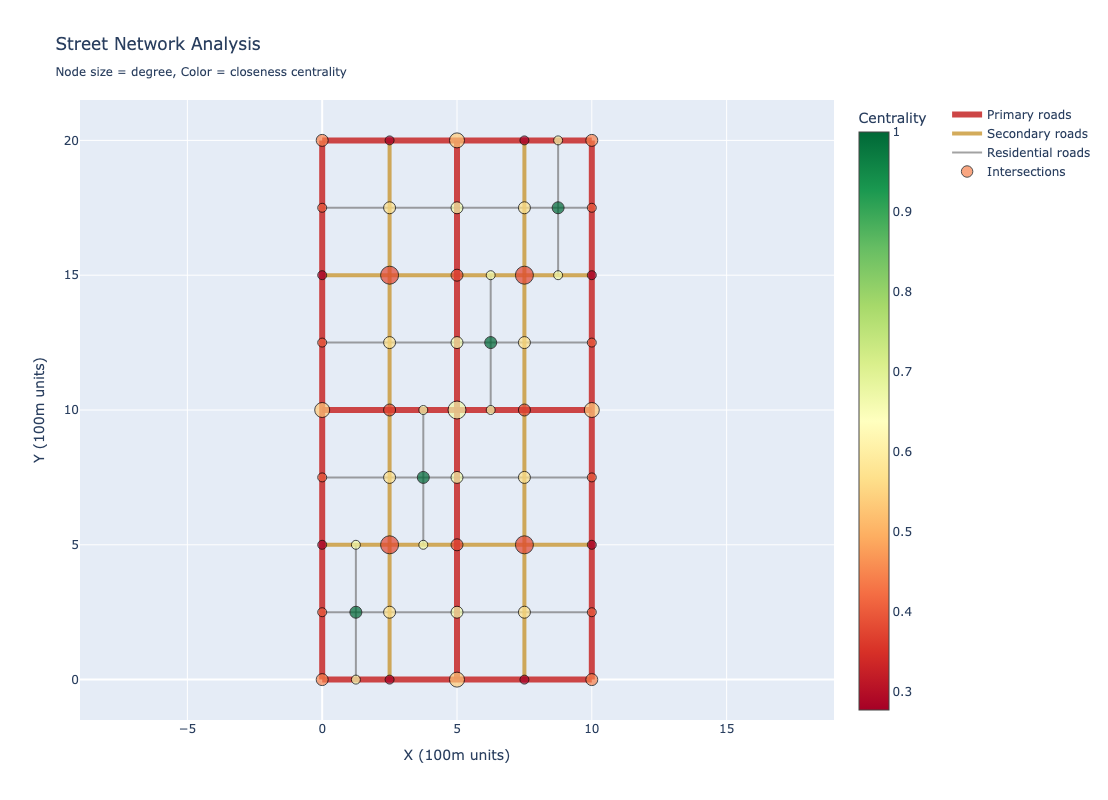

In [9]:
def visualize_street_network(street_data, degrees, centralities):
    """Create visualization of street network."""
    fig = go.Figure()
    
    # Color map for street types
    type_colors = {
        'primary': 'rgba(200, 50, 50, 0.9)',
        'secondary': 'rgba(200, 150, 50, 0.8)',
        'residential': 'rgba(100, 100, 100, 0.6)'
    }
    
    type_widths = {
        'primary': 6,
        'secondary': 4,
        'residential': 2
    }
    
    # Draw streets by type
    for stype in ['residential', 'secondary', 'primary']:  # Draw in order (primary on top)
        for i, edge in enumerate(street_data['edges']):
            attr = street_data['edge_attributes'][i]
            if attr['street_type'] != stype:
                continue
            
            start, end = edge.Vertices()
            start_c = start.Coordinates()
            end_c = end.Coordinates()
            
            fig.add_trace(go.Scatter(
                x=[start_c[0], end_c[0]],
                y=[start_c[1], end_c[1]],
                mode='lines',
                line=dict(
                    color=type_colors.get(stype, 'gray'),
                    width=type_widths.get(stype, 2)
                ),
                name=attr['street_name'],
                showlegend=False,
                hovertext=f"{attr['street_name']} ({stype})",
                hoverinfo='text'
            ))
    
    # Add legend entries for street types
    for stype, color in type_colors.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='lines',
            line=dict(color=color, width=type_widths[stype]),
            name=f"{stype.capitalize()} roads"
        ))
    
    # Draw intersections colored by centrality
    x = [d['x'] for d in degrees]
    y = [d['y'] for d in degrees]
    c = [d['centrality'] for d in degrees]
    deg = [d['degree'] for d in degrees]
    
    # Size based on degree
    sizes = [6 + d['degree'] * 3 for d in degrees]
    
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='markers',
        marker=dict(
            size=sizes,
            color=c,
            colorscale='RdYlGn',
            colorbar=dict(title='Centrality'),
            line=dict(color='black', width=1)
        ),
        text=[f"Degree: {d}, Centrality: {c:.3f}" for d, c in zip(deg, c)],
        hoverinfo='text',
        name='Intersections'
    ))
    
    fig.update_layout(
        title='Street Network Analysis<br><sub>Node size = degree, Color = closeness centrality</sub>',
        xaxis=dict(
            title='X (100m units)',
            scaleanchor='y',
            scaleratio=1
        ),
        yaxis=dict(title='Y (100m units)'),
        width=900,
        height=800,
        showlegend=True,
        legend=dict(x=1.15, y=1)
    )
    
    return fig

fig_network = visualize_street_network(street_data, degrees, centralities)
fig_network.show()

## 6. Analyze Streets by Name

In [10]:
# Group edges by street name
streets_by_name = defaultdict(lambda: {'segments': 0, 'length': 0.0, 'type': None})

for attr in street_data['edge_attributes']:
    name = attr['street_name']
    streets_by_name[name]['segments'] += 1
    streets_by_name[name]['length'] += attr['length'] * 100  # Convert to meters
    streets_by_name[name]['type'] = attr['street_type']

# Sort by length
sorted_streets = sorted(streets_by_name.items(), key=lambda x: -x[1]['length'])

print("Streets by Total Length:")
print("=" * 60)
print(f"{'Street Name':<20} {'Type':<12} {'Segments':>8} {'Length (m)':>12}")
print("-" * 60)

for name, data in sorted_streets:
    print(f"{name:<20} {data['type']:<12} {data['segments']:>8} {data['length']:>12.0f}")

Streets by Total Length:
Street Name          Type         Segments   Length (m)
------------------------------------------------------------
Main Street          primary             2         2000
Central Avenue       primary             2         2000
Park Boulevard       primary             2         2000
Oak Street           secondary           4         2000
Elm Street           secondary           4         2000
South Street         primary             2         1000
High Street          primary             2         1000
North Street         primary             2         1000
Queen Street         secondary           4         1000
King Street          secondary           4         1000
Maple Lane           residential         2          500
Pine Way             residential         2          500
Cedar Court          residential         2          500
Birch Road           residential         2          500
Willow Street        residential         2          500
Ash Lane          

## 7. Shortest Path Analysis

In [11]:
# Find shortest paths between key locations
graph_vertices = street_graph.Vertices()

# Get vertex by approximate coordinates
def get_vertex_near(x, y, tolerance=0.5):
    for v in graph_vertices:
        coords = v.Coordinates()
        if abs(coords[0] - x) < tolerance and abs(coords[1] - y) < tolerance:
            return v
    return None

# Define key locations
locations = {
    'SW Corner': (0, 0),
    'SE Corner': (10, 0),
    'NW Corner': (0, 20),
    'NE Corner': (10, 20),
    'Center': (5, 10),
    'Central South': (5, 0),
    'Central North': (5, 20)
}

# Calculate paths between selected pairs
path_pairs = [
    ('SW Corner', 'NE Corner'),
    ('SE Corner', 'NW Corner'),
    ('Center', 'SW Corner'),
    ('Central South', 'Central North')
]

print("Shortest Path Analysis:")
print("=" * 60)

paths_data = []

for start_name, end_name in path_pairs:
    start_coords = locations[start_name]
    end_coords = locations[end_name]
    
    start_v = get_vertex_near(*start_coords)
    end_v = get_vertex_near(*end_coords)
    
    if start_v and end_v:
        distance = street_graph.Distance(start_v, end_v)
        path = street_graph.Path(start_v, end_v)
        
        if path:
            path_vertices = path.Vertices()
            path_length_m = path.Length() * 100  # Convert to meters
            
            paths_data.append({
                'from': start_name,
                'to': end_name,
                'hops': distance,
                'length': path_length_m,
                'path': path
            })
            
            print(f"\n{start_name} -> {end_name}:")
            print(f"  Distance: {distance} intersection(s)")
            print(f"  Path length: {path_length_m:.0f} meters")

Shortest Path Analysis:

SW Corner -> NE Corner:
  Distance: 4 intersection(s)
  Path length: 3000 meters

SE Corner -> NW Corner:
  Distance: 4 intersection(s)
  Path length: 3000 meters

Center -> SW Corner:
  Distance: 2 intersection(s)
  Path length: 1500 meters

Central South -> Central North:
  Distance: 2 intersection(s)
  Path length: 2000 meters


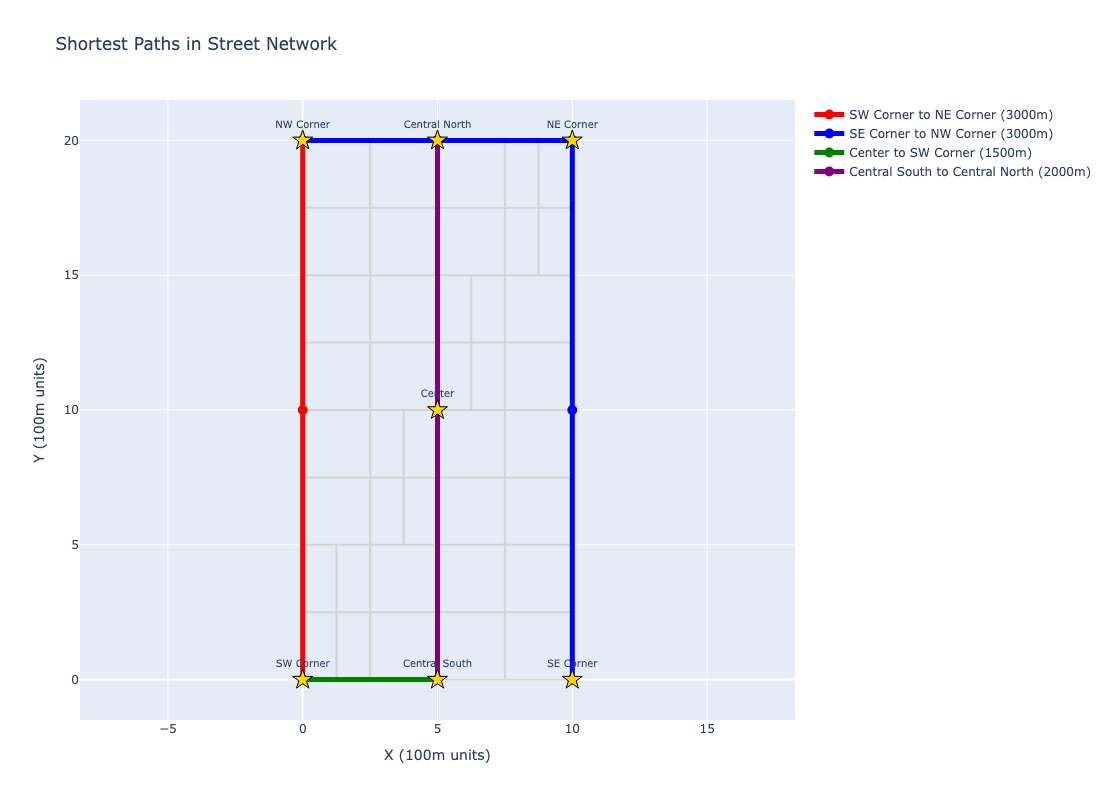

In [12]:
def visualize_paths(street_data, paths_data):
    """Visualize specific paths on the network."""
    fig = go.Figure()
    
    # Draw all streets in gray
    for edge in street_data['edges']:
        start, end = edge.Vertices()
        start_c = start.Coordinates()
        end_c = end.Coordinates()
        
        fig.add_trace(go.Scatter(
            x=[start_c[0], end_c[0]],
            y=[start_c[1], end_c[1]],
            mode='lines',
            line=dict(color='lightgray', width=2),
            showlegend=False,
            hoverinfo='skip'
        ))
    
    # Draw paths with different colors
    path_colors = ['red', 'blue', 'green', 'purple']
    
    for i, pdata in enumerate(paths_data):
        path = pdata['path']
        color = path_colors[i % len(path_colors)]
        
        path_vertices = path.Vertices()
        x = [v.Coordinates()[0] for v in path_vertices]
        y = [v.Coordinates()[1] for v in path_vertices]
        
        fig.add_trace(go.Scatter(
            x=x, y=y,
            mode='lines+markers',
            line=dict(color=color, width=5),
            marker=dict(size=10, color=color),
            name=f"{pdata['from']} to {pdata['to']} ({pdata['length']:.0f}m)"
        ))
    
    # Mark key locations
    for name, (x, y) in locations.items():
        fig.add_trace(go.Scatter(
            x=[x], y=[y],
            mode='markers+text',
            marker=dict(size=15, color='gold', symbol='star', line=dict(color='black', width=1)),
            text=[name],
            textposition='top center',
            textfont=dict(size=10),
            showlegend=False,
            hoverinfo='text',
            hovertext=name
        ))
    
    fig.update_layout(
        title='Shortest Paths in Street Network',
        xaxis=dict(title='X (100m units)', scaleanchor='y', scaleratio=1),
        yaxis=dict(title='Y (100m units)'),
        width=900,
        height=800,
        showlegend=True,
        legend=dict(x=1.02, y=1)
    )
    
    return fig

fig_paths = visualize_paths(street_data, paths_data)
fig_paths.show()

## 8. Degree Distribution Visualization

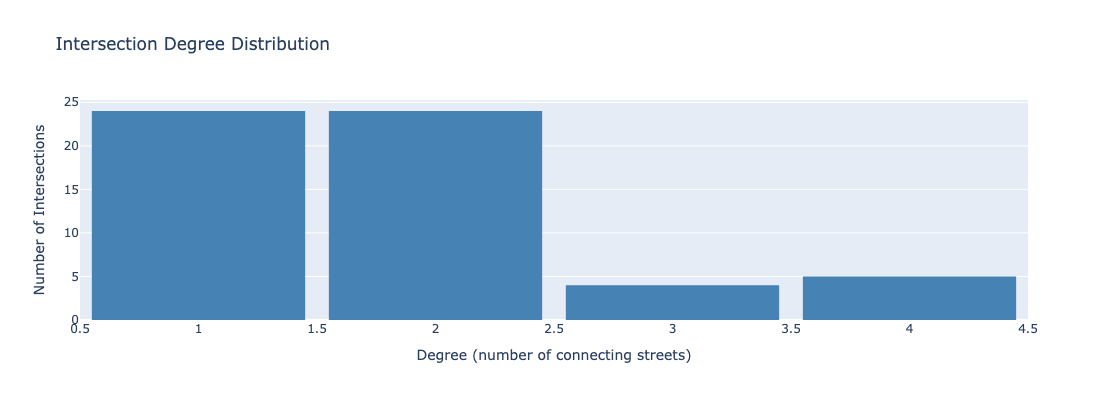

In [13]:
# Create bar chart of degree distribution
fig_dist = go.Figure()

degrees_list = [d['degree'] for d in degrees]

fig_dist.add_trace(go.Histogram(
    x=degrees_list,
    nbinsx=max(degrees_list),
    marker_color='steelblue',
    name='Degree Distribution'
))

fig_dist.update_layout(
    title='Intersection Degree Distribution',
    xaxis_title='Degree (number of connecting streets)',
    yaxis_title='Number of Intersections',
    width=700,
    height=400,
    bargap=0.1
)

fig_dist.show()

## 9. Network Statistics Summary

In [14]:
# Compile network statistics
stats = {
    'Total Intersections': street_graph.Order(),
    'Total Street Segments': street_graph.Size(),
    'Network Length (km)': sum(type_lengths.values()) * 100 / 1000,
    'Primary Roads (km)': type_lengths['primary'] * 100 / 1000,
    'Secondary Roads (km)': type_lengths['secondary'] * 100 / 1000,
    'Residential Streets (km)': type_lengths['residential'] * 100 / 1000,
    'Graph Density': street_graph.Density(),
    'Network Diameter': street_graph.Diameter(),
    'Average Degree': sum(degrees_list) / len(degrees_list),
    'Max Degree': max(degrees_list),
    'Min Degree': min(degrees_list),
    'Dead Ends': degree_dist.get(1, 0),
    '3-Way Junctions': degree_dist.get(3, 0),
    '4-Way Intersections': degree_dist.get(4, 0),
    'Average Centrality': sum(centralities) / len(centralities)
}

print("Street Network Statistics Summary")
print("=" * 50)
for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key:<30}: {value:.3f}")
    else:
        print(f"{key:<30}: {value}")

Street Network Statistics Summary
Total Intersections           : 57
Total Street Segments         : 52
Network Length (km)           : 21.000
Primary Roads (km)            : 9.000
Secondary Roads (km)          : 6.000
Residential Streets (km)      : 6.000
Graph Density                 : 0.033
Network Diameter              : 6
Average Degree                : 1.825
Max Degree                    : 4
Min Degree                    : 1
Dead Ends                     : 24
3-Way Junctions               : 4
4-Way Intersections           : 5
Average Centrality            : 0.519


## Summary

This notebook demonstrated:

1. **Street Network Creation** - Built a realistic street grid programmatically
2. **Graph Analysis** - Used `tf.Graph` for network metrics
3. **Centrality Calculation** - Implemented closeness centrality algorithm
4. **Path Finding** - Found shortest paths between locations
5. **Visualization** - Created interactive Plotly maps

### Key Differences from topologicpy:

- **No OSM Import**: topologic_fast doesn't have `Topology.ByDXFPath()` or OSM XML parsing
- **No Built-in Centrality**: We implemented closeness centrality manually
- **No Quotient Graph**: topologic_fast doesn't have `Graph.Quotient()` for street-level aggregation
- **No Line Graph**: topologic_fast doesn't have `Graph.LineGraph()` transformation
- **No Color Class**: We use Plotly color scales directly

### Applications:
- **Urban Planning**: Analyze street connectivity and accessibility
- **Transportation**: Route planning and network design
- **Emergency Services**: Identify critical network nodes
- **Real Estate**: Evaluate location centrality